# Problem 1 — Data generation and code-reading demo
This notebook generates Xi ~ N(1,1), Ui|Xi ~ N(0, Xi^2), and Yi = beta0 + Xi*beta1 + Ui for n=10.
It also demonstrates two ways to programmatically read code cells from an .ipynb file.

In [3]:
%pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 33.2 MB/s  0:00:00eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd

def generate_data(n=10, beta0=1.0, beta1=1.0, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.normal(loc=1.0, scale=1.0, size=n)
    U = np.array([rng.normal(loc=0.0, scale=abs(x)) for x in X])
    Y = beta0 + X * beta1 + U
    return X, U, Y

In [5]:
# Generate and display the data
X, U, Y = generate_data(n=10, seed=123)
df = pd.DataFrame({'X': X, 'U': U, 'Y': Y})
df

,X,U,Y
0,0.010879,0.001057,1.011936
1,0.632213,-0.964714,0.667500
2,2.287925,2.727587,6.015512
3,1.193974,-0.801264,1.392711
4,1.920231,1.920748,4.840979
5,1.577104,0.214993,2.792096
6,0.363536,0.556950,1.920486
7,1.541952,-1.017641,1.524311
8,0.683405,-0.213082,1.470323
9,0.677611,0.228876,1.906487


In [6]:
# Save to CSV
df.to_csv('problem1_data.csv', index=False)
print('Saved problem1_data.csv')

Saved problem1_data.csv


# Analysis: OLS and robust standard errors

This section computes the OLS estimates, HC1 robust standard errors, and a 95% confidence interval for \beta_1 using the saved `problem1_data.csv`.

In [7]:
import numpy as np
import pandas as pd

# Read the simulated data
try:
    df = pd.read_csv('problem1_data.csv')
except Exception as e:
    print('Failed to read problem1_data.csv:', e)
    df = pd.DataFrame()

if not df.empty:
    print('Data preview:')
    print(df.head())

    # Prepare matrices
    n = df.shape[0]
    X = np.column_stack((np.ones(n), df['X'].values))
    y = df['Y'].values.reshape(-1, 1)
    k = X.shape[1]

    # OLS estimates
    XtX_inv = np.linalg.inv(X.T @ X)
    beta_hat = (XtX_inv @ X.T @ y).reshape(-1)
    y_hat = (X @ beta_hat.reshape(-1,1)).reshape(-1)
    resid = (y.reshape(-1) - y_hat)

    # HC1 robust variance estimator
    S = np.diag(resid ** 2)
    meat = X.T @ S @ X
    scale = n / (n - k)
    var_beta_hat = scale * XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.diag(var_beta_hat))

    print('\nOLS estimates (beta0, beta1):', beta_hat)
    print('HC1 robust SEs (se0, se1):', se)

    # 95% CI for beta1 (use t critical value if scipy available, else normal approx)
    try:
        from scipy import stats
        dfree = n - k
        tcrit = stats.t.ppf(0.975, dfree)
    except Exception:
        tcrit = 1.96
    lower = beta_hat[1] - tcrit * se[1]
    upper = beta_hat[1] + tcrit * se[1]
    print(f'95% CI for beta1: [{lower:.4f}, {upper:.4f}] (tcrit={tcrit:.4f})')
else:
    print('Dataframe is empty; run the data generation cell first.')

Data preview:
          X         U         Y
0  0.010879  0.001057  1.011936
1  0.632213 -0.964714  0.667500
2  2.287925  2.727587  6.015512
3  1.193974 -0.801264  1.392711
4  1.920231  1.920748  4.840979

OLS estimates (beta0, beta1): [0.25770501 1.92539412]
HC1 robust SEs (se0, se1): [0.53339976 0.52519067]
95% CI for beta1: [0.8960, 2.9548] (tcrit=1.9600)


In [9]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 32.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 38.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [10]:
# Optional: use statsmodels for comparison if available
try:
    import statsmodels.api as sm
    model = sm.OLS(df['Y'], sm.add_constant(df['X'])).fit(cov_type='HC1')
    print('\nStatsmodels OLS summary with HC1 robust SEs:')
    print(model.summary())
except Exception as e:
    print('statsmodels not available or failed to run:', e)


Statsmodels OLS summary with HC1 robust SEs:
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     13.44
Date:                Fri, 16 Jan 2026   Prob (F-statistic):            0.00635
Time:                        12:12:49   Log-Likelihood:                -13.861
No. Observations:                  10   AIC:                             31.72
Df Residuals:                       8   BIC:                             32.33
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const 

## Question 1
This section runs the repeated experiments requested:

1. Generate data: X_i ~ N(1,1), U_i|X_i ~ N(0, X_i^2), Y_i = beta0 + beta1*X_i + U_i with beta0=beta1=1.
2. Compute OLS (beta0,beta1) and HC1 robust SEs, build 95% CI for beta1.
3. Check if CI contains true beta1=1.
4. Repeat 1000 times and report coverage and histogram of beta1_hat.
5. Repeat for sample sizes n in [10,50,100,500,1000].

In [12]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 25.7 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.5 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 35.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helper functions

def generate_data(n, beta0=1.0, beta1=1.0, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.normal(loc=1.0, scale=1.0, size=n)
    U = np.array([rng.normal(loc=0.0, scale=abs(x)) for x in X])
    Y = beta0 + X * beta1 + U
    return X, Y


def ols_hc1(X, Y):
    n = len(Y)
    Xmat = np.column_stack((np.ones(n), X))
    XtX_inv = np.linalg.inv(Xmat.T @ Xmat)
    beta = XtX_inv @ Xmat.T @ Y
    resid = Y - Xmat @ beta
    S = np.diag(resid ** 2)
    k = Xmat.shape[1]
    meat = Xmat.T @ S @ Xmat
    scale = n / (n - k)
    var_beta = scale * XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.diag(var_beta))
    return beta, se


def run_experiment(n, trials=1000, seed=None):
    rng = np.random.default_rng(seed)
    beta1_estimates = np.empty(trials)
    covered = 0
    for t in range(trials):
        s = rng.integers(0, 2**31 - 1)
        X, Y = generate_data(n, seed=s)
        beta, se = ols_hc1(X, Y)
        beta1 = float(beta[1])
        beta1_estimates[t] = beta1
        # t-critical value (use t with df = n-2 if scipy available)
        try:
            from scipy import stats
            tcrit = stats.t.ppf(0.975, n - 2)
        except Exception:
            tcrit = 1.96
        lower = beta1 - tcrit * se[1]
        upper = beta1 + tcrit * se[1]
        if lower <= 1.0 <= upper:
            covered += 1
    return beta1_estimates, covered

# Plot helper

def plot_hist(beta1_estimates, n, trials):
    plt.figure(figsize=(7,4))
    plt.hist(beta1_estimates, bins=30, color='C0', alpha=0.8)
    plt.axvline(1.0, color='k', linestyle='--', label='True beta1=1')
    plt.title(f'Histogram of beta1_hat (n={n}, trials={trials})')
    plt.xlabel('beta1_hat')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


n=10, trials=1000: coverage count = 836, coverage pct = 83.60%


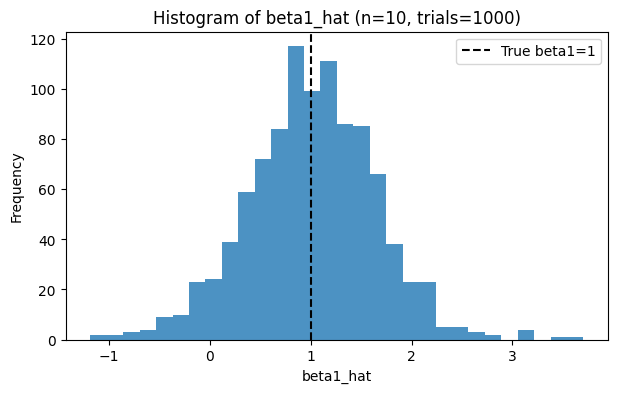

n=10: coverage = 854/1000 (85.40%)
n=50: coverage = 923/1000 (92.30%)
n=100: coverage = 923/1000 (92.30%)
n=500: coverage = 947/1000 (94.70%)
n=1000: coverage = 957/1000 (95.70%)


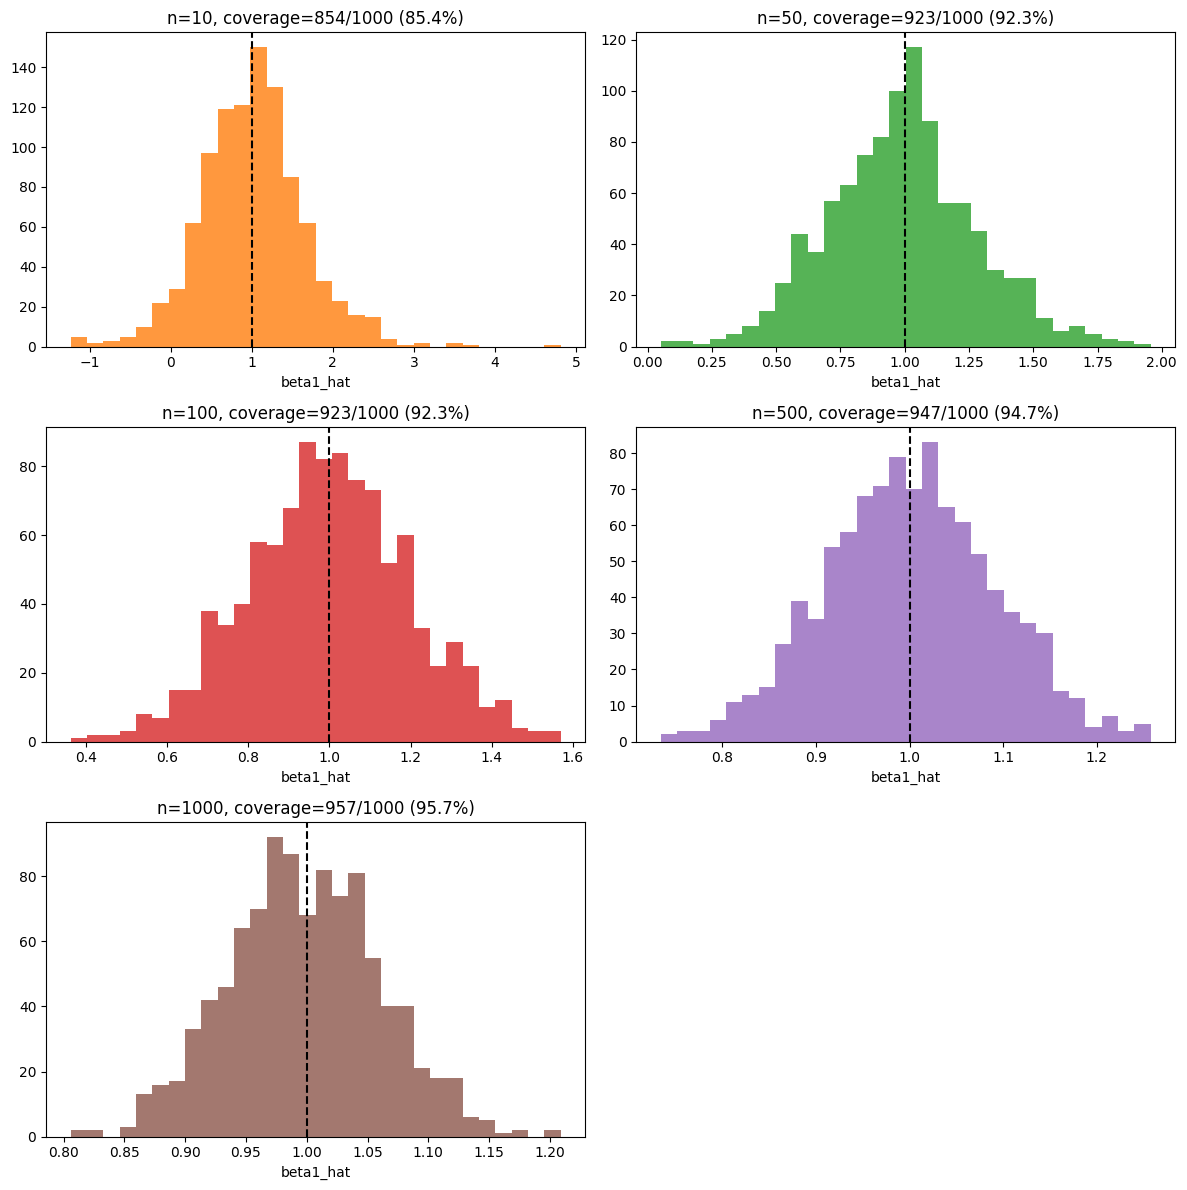


Saved coverage_summary.csv


In [14]:
# 1-4: Run the experiment for n=10 (trials=1000)
n = 10
trials = 1000
beta1_estimates_10, covered_10 = run_experiment(n, trials=trials, seed=2026)
coverage_pct_10 = covered_10 / trials * 100
print(f'n={n}, trials={trials}: coverage count = {covered_10}, coverage pct = {coverage_pct_10:.2f}%')
plot_hist(beta1_estimates_10, n, trials)

# 5: Repeat for multiple sample sizes
sample_sizes = [10, 50, 100, 500, 1000]
results = []
for n in sample_sizes:
    beta1_estimates, covered = run_experiment(n, trials=1000, seed=12345 + n)
    pct = covered / 1000 * 100
    results.append((n, covered, pct, beta1_estimates))
    print(f'n={n}: coverage = {covered}/1000 ({pct:.2f}%)')

# Plot histograms for each n in a grid
import math
cols = 2
rows = math.ceil(len(sample_sizes)/cols)
plt.figure(figsize=(12, 4*rows))
for i, (n, covered, pct, beta1_estimates) in enumerate(results, 1):
    plt.subplot(rows, cols, i)
    plt.hist(beta1_estimates, bins=30, color=f'C{i%10}', alpha=0.8)
    plt.axvline(1.0, color='k', linestyle='--')
    plt.title(f'n={n}, coverage={covered}/1000 ({pct:.1f}%)')
    plt.xlabel('beta1_hat')
plt.tight_layout()
plt.show()

# Save summary results
summary = pd.DataFrame([(n, covered, pct) for (n, covered, pct, _) in results], columns=['n','covered_count','covered_pct'])
summary.to_csv('coverage_summary.csv', index=False)
print('\nSaved coverage_summary.csv')
